 Sales Prediction using Machine Learning




## 1. Import Required Libraries




In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning - models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Machine Learning - evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Saving the model
import joblib

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# To keep results reproducible
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset




In [ ]:
# Load the advertising dataset
df = pd.read_csv("advertising.csv")

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

Dataset loaded successfully.
Shape of the dataset: (200, 4)


## 3. Display First Five and Last Five Records




In [ ]:
# First five records
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
# Last five records
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


## 4. Explore the Dataset




In [ ]:
# Shape of the dataset
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (200, 4)


In [ ]:
# Column names
print("Columns:", list(df.columns))

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


In [ ]:
# Data types of each column
df.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [ ]:
# Check for missing values
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
# Check for duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Statistical summary of the dataset
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 5. Data Cleaning




In [ ]:
# 9.1 Handle Missing Values
# Since the dataset is numeric, missing values (if any) are filled with the column median.
missing_before = df.isnull().sum().sum()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

missing_after = df.isnull().sum().sum()
print(f"Missing values before cleaning: {missing_before}")
print(f"Missing values after cleaning: {missing_after}")

Missing values before cleaning: 0
Missing values after cleaning: 0


In [ ]:
# 9.2 Remove Duplicate Records
rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates: {rows_after}")

Rows before removing duplicates: 200
Rows after removing duplicates: 200


In [ ]:
# 9.3 Verify Data Consistency
# Ensure no negative advertising budgets or negative sales exist (which would be invalid)
print("Any negative values present?")
print((df < 0).sum())

df = df.reset_index(drop=True)
print("\nData cleaning complete. Final shape:", df.shape)

Any negative values present?
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Data cleaning complete. Final shape: (200, 4)


## 6. Exploratory Data Analysis (EDA)




### 6.1 Sales Distribution

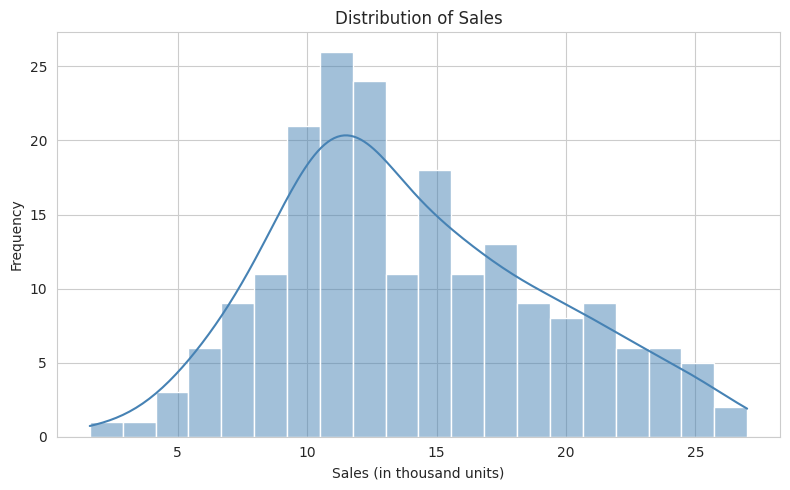

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], kde=True, color="steelblue", bins=20)
plt.title("Distribution of Sales")
plt.xlabel("Sales (in thousand units)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 6.2 Advertising Budget Distribution

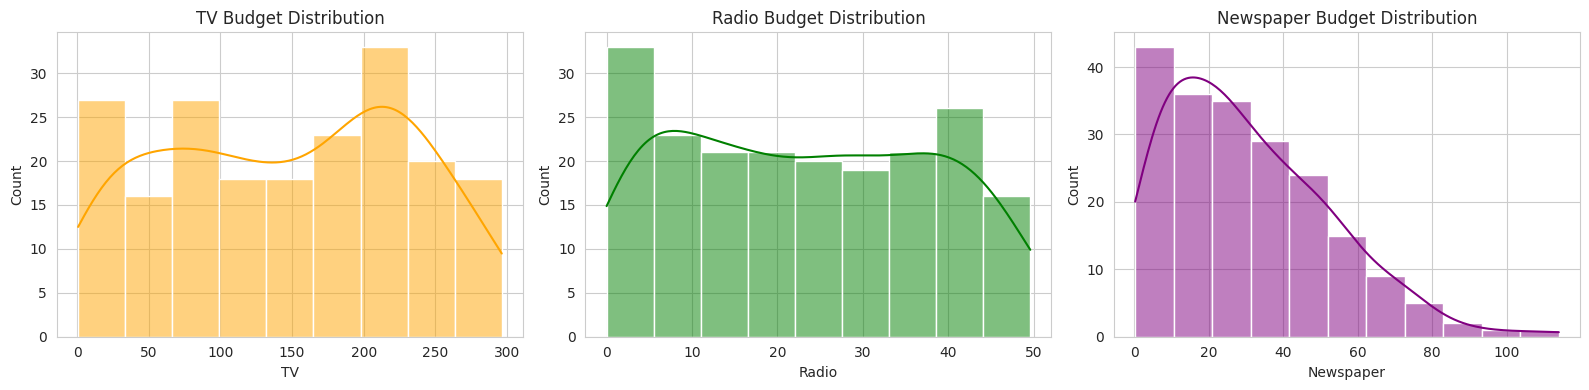

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["TV"], kde=True, ax=axes[0], color="orange")
axes[0].set_title("TV Budget Distribution")

sns.histplot(df["Radio"], kde=True, ax=axes[1], color="green")
axes[1].set_title("Radio Budget Distribution")

sns.histplot(df["Newspaper"], kde=True, ax=axes[2], color="purple")
axes[2].set_title("Newspaper Budget Distribution")

plt.tight_layout()
plt.show()

### 6.3 Correlation Heatmap

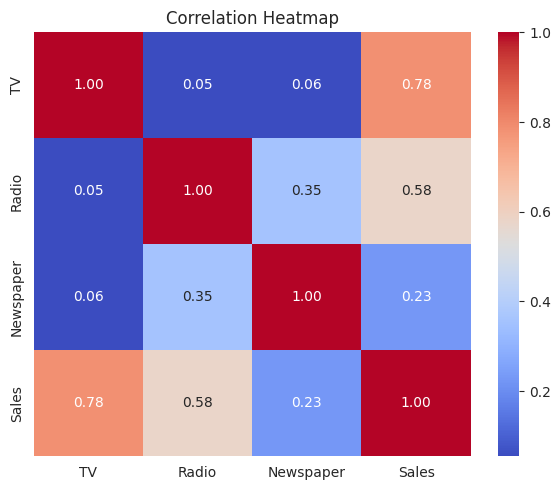

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [ ]:
plt.figure(figsize=(6, 5))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print(correlation_matrix["Sales"].sort_values(ascending=False))

### 6.4 Pair Plot

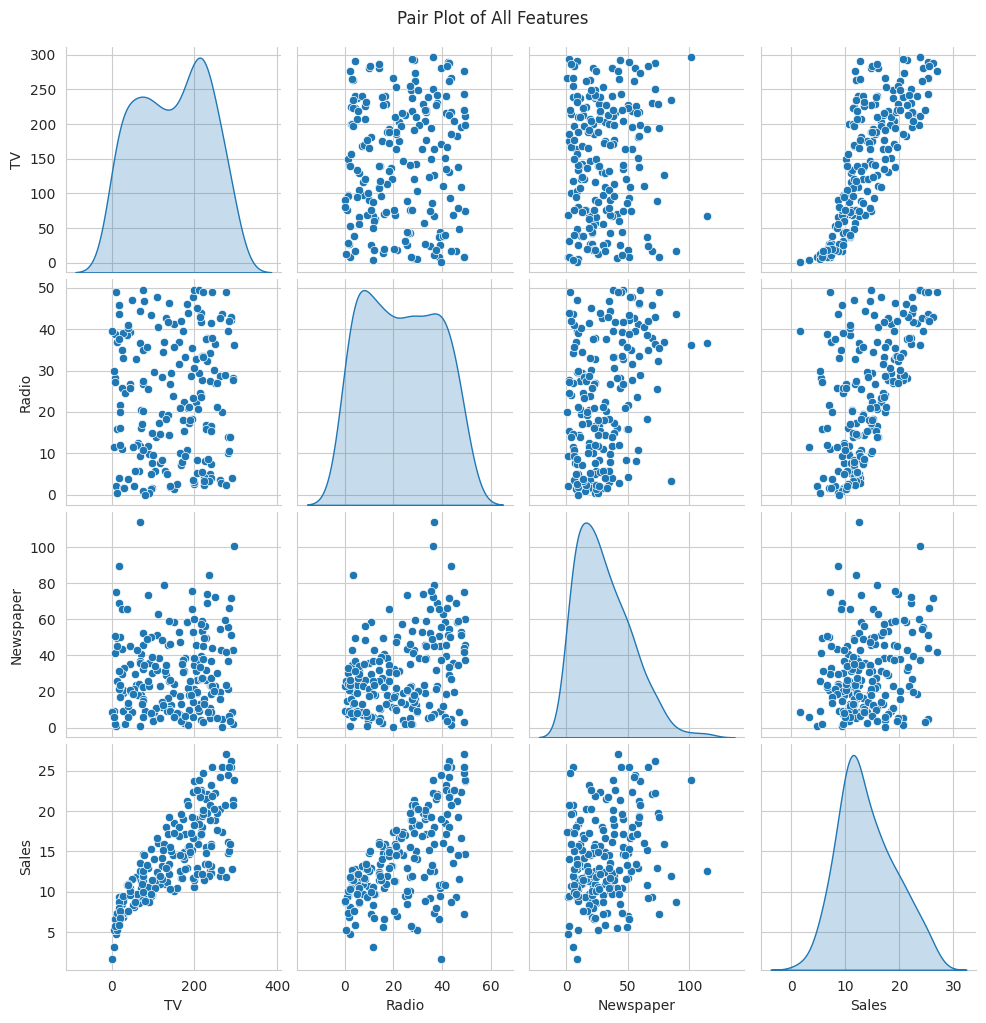

In [ ]:
sns.pairplot(df, diag_kind="kde")
plt.suptitle("Pair Plot of All Features", y=1.02)
plt.show()

### 6.5 Scatter Plots: TV, Radio, Newspaper vs Sales

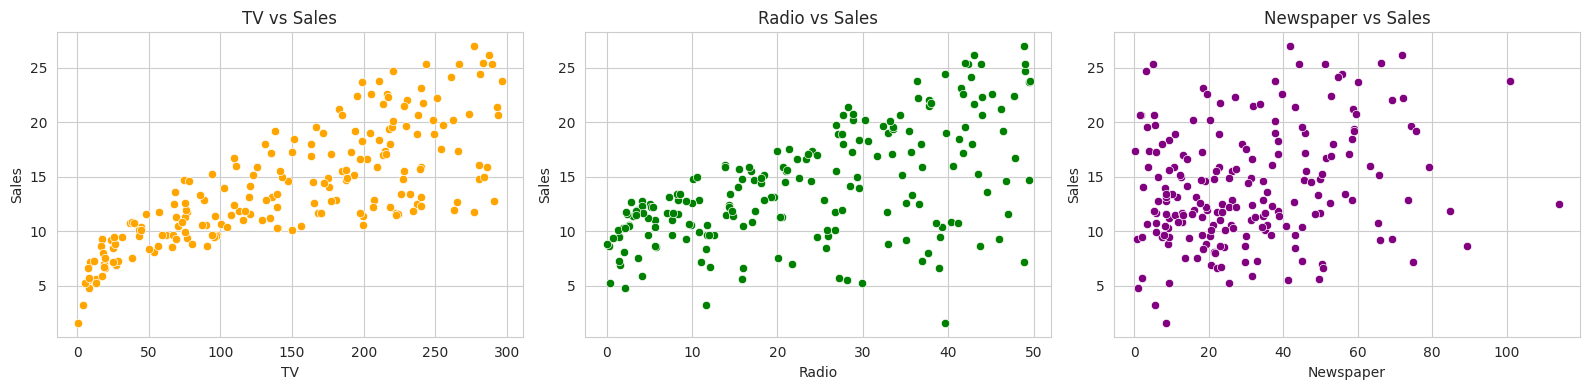

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(x="TV", y="Sales", data=df, ax=axes[0], color="orange")
axes[0].set_title("TV vs Sales")

sns.scatterplot(x="Radio", y="Sales", data=df, ax=axes[1], color="green")
axes[1].set_title("Radio vs Sales")

sns.scatterplot(x="Newspaper", y="Sales", data=df, ax=axes[2], color="purple")
axes[2].set_title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

### 6.6 Box Plots (Outlier Detection)

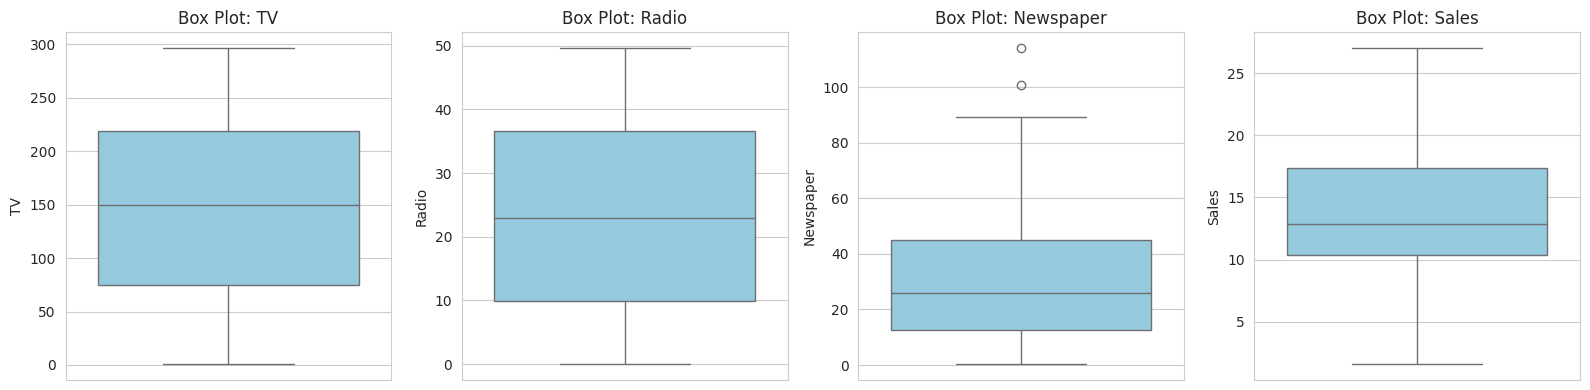

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, df.columns):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Box Plot: {col}")

plt.tight_layout()
plt.show()

### 6.7 Histograms (All Features)

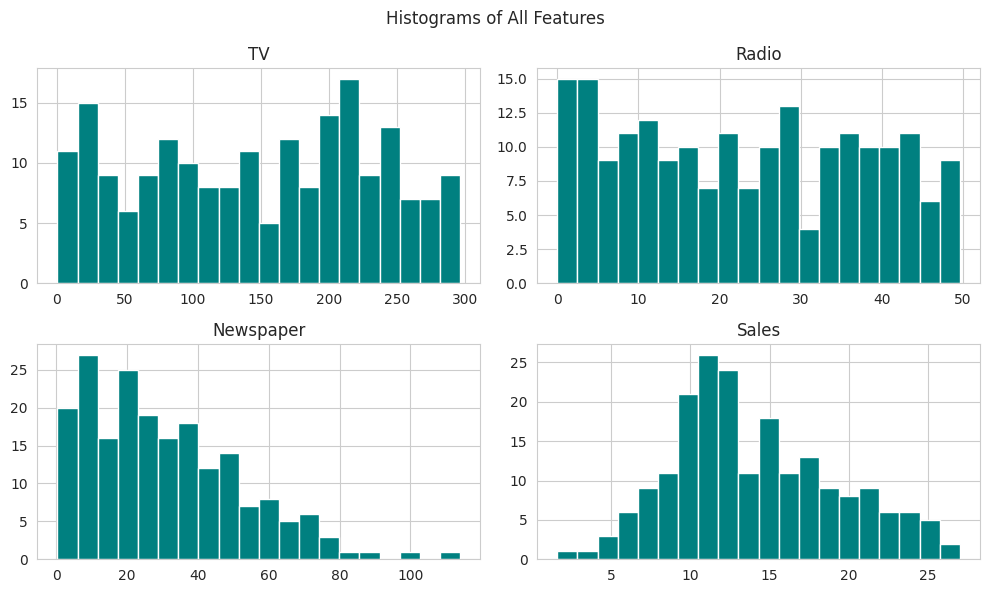

In [ ]:
df.hist(figsize=(10, 6), color="teal", bins=20)
plt.suptitle("Histograms of All Features")
plt.tight_layout()
plt.show()

## 7. Feature Engineering




In [ ]:
# Verify there are no categorical columns to encode
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns found:", categorical_cols)

# All features in this dataset are already numeric, so no encoding is necessary.
print("No categorical encoding required — all features are numeric.")

Categorical columns found: []
No categorical encoding required — all features are numeric.


## 8. Feature Selection




In [ ]:
# Independent variables (features)
X = df[["TV", "Radio", "Newspaper"]]

# Dependent variable (target)
y = df["Sales"]

print("Feature set (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Feature set (X) shape: (200, 3)
Target (y) shape: (200,)


## 9. Split the Dataset into Training and Testing Sets




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (160, 3)
Testing set size: (40, 3)


## 10. Train Multiple Regression Models



In [ ]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained.")

Linear Regression model trained.


In [ ]:
# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
print("Decision Tree Regressor model trained.")

Decision Tree Regressor model trained.


In [ ]:
# 3. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained.")

Random Forest Regressor model trained.


## 11. Compare All Models


In [ ]:
def evaluate_model(name, model, X_test, y_test):
    """Calculate and return regression evaluation metrics for a trained model."""
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return {
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
    }

results = []
results.append(evaluate_model("Linear Regression", lr_model, X_test, y_test))
results.append(evaluate_model("Decision Tree Regressor", dt_model, X_test, y_test))
results.append(evaluate_model("Random Forest Regressor", rf_model, X_test, y_test))

results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.8994,1.4608,3.1741,1.7816
1,Decision Tree Regressor,0.9311,0.9850,2.1750,1.4748
2,Random Forest Regressor,0.9813,0.6201,0.5907,0.7686


/tmp/ipykernel_1984/768701564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")


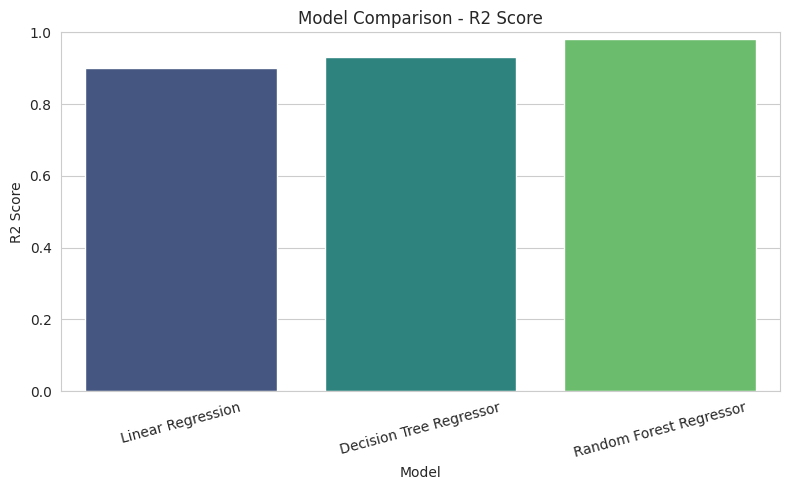

In [ ]:
# Visual comparison of R2 scores
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")
plt.title("Model Comparison - R2 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 12. Select the Best-Performing Model



In [ ]:
best_model_row = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]
best_model_name = best_model_row["Model"]

model_dict = {
    "Linear Regression": lr_model,
    "Decision Tree Regressor": dt_model,
    "Random Forest Regressor": rf_model,
}
best_model = model_dict[best_model_name]

print(f"Best Performing Model: {best_model_name}")
print(f"R2 Score: {best_model_row['R2 Score']}")
print(f"RMSE: {best_model_row['RMSE']}")

Best Performing Model: Random Forest Regressor
R2 Score: 0.9813
RMSE: 0.7686


## 13. Predict Sales on the Test Dataset




In [ ]:
y_pred_best = best_model.predict(X_test)

print("Predictions generated for", len(y_pred_best), "test records.")
print("Sample predictions:", np.round(y_pred_best[:5], 2))

Predictions generated for 40 test records.
Sample predictions: [17.7  21.8  20.63  6.79 22.93]


## 14. Compare Actual vs Predicted Sales




In [ ]:
comparison_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": np.round(y_pred_best, 2)
})
comparison_df["Difference"] = np.round(
    comparison_df["Actual Sales"] - comparison_df["Predicted Sales"], 2
)

comparison_df.head(10)

,Actual Sales,Predicted Sales,Difference
0,16.9,17.70,-0.80
1,22.4,21.80,0.60
2,21.4,20.63,0.77
3,7.3,6.79,0.51
4,24.7,22.93,1.77
5,12.6,13.38,-0.78
6,22.3,22.38,-0.08
7,8.4,9.69,-1.29
8,11.5,11.83,-0.33
9,14.9,15.54,-0.64


## 15. Visualizations: Actual vs Predicted, Residuals, Feature Importance

### 15.1 Actual vs Predicted Sales

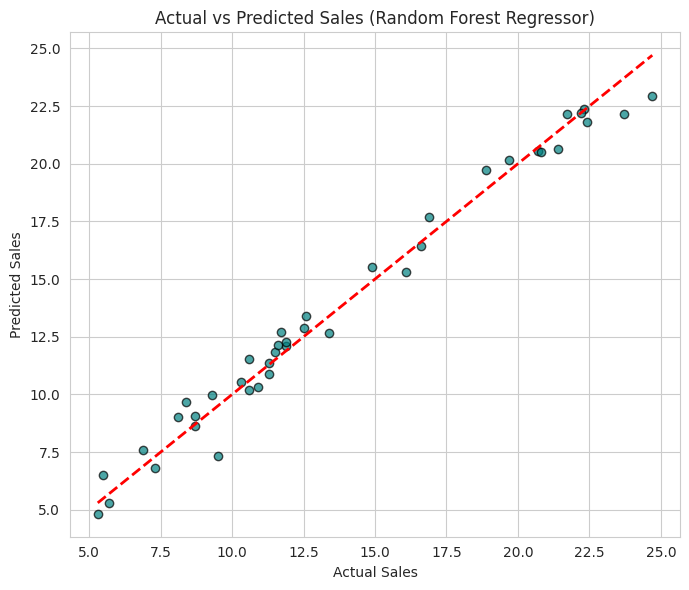

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, color="teal", alpha=0.7, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales ({best_model_name})")
plt.tight_layout()
plt.show()

### 15.2 Residual Plot

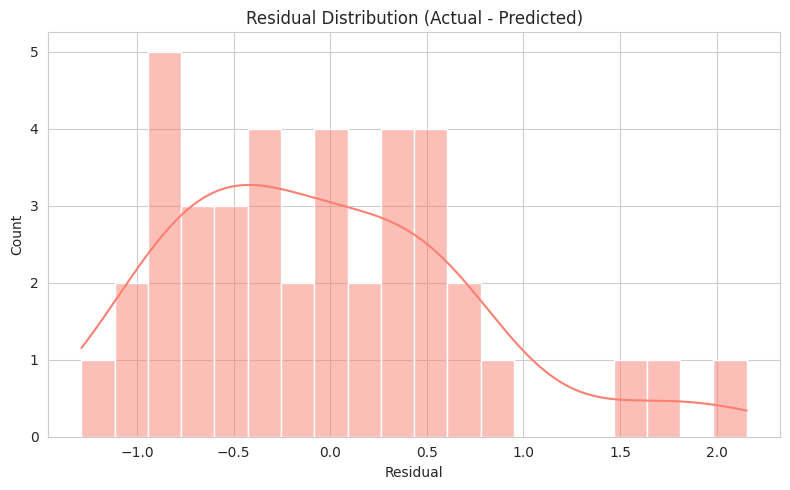

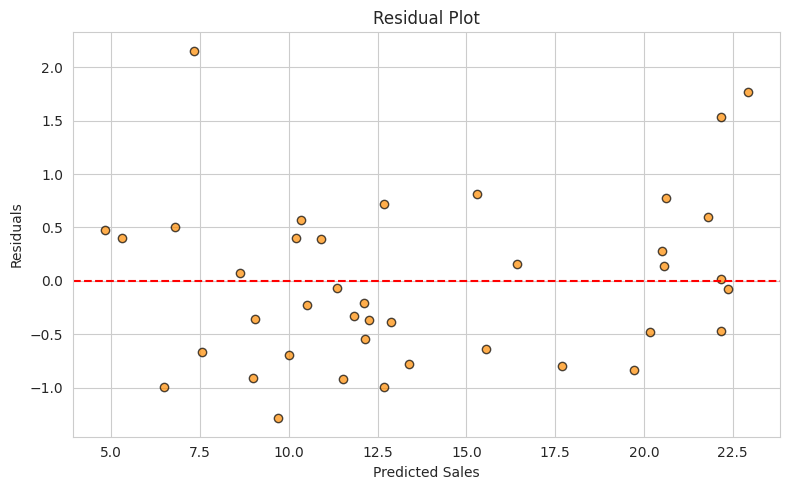

In [ ]:
residuals = y_test.values - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="salmon", bins=20)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, color="darkorange", alpha=0.7, edgecolor="k")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

### 15.3 Feature Importance

/tmp/ipykernel_1984/405230532.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="magma")


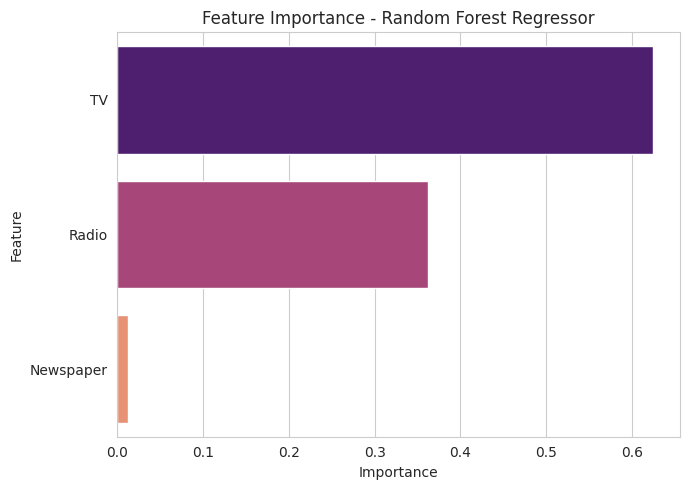

     Feature  Importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989


In [ ]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(7, 5))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="magma")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(importance_df)

elif hasattr(best_model, "coef_"):
    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": best_model.coef_
    }).sort_values(by="Coefficient", ascending=False)

    plt.figure(figsize=(7, 5))
    sns.barplot(x="Coefficient", y="Feature", data=coef_df, palette="magma")
    plt.title(f"Feature Coefficients - {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(coef_df)
else:
    print("Feature importance is not supported for this model type.")

## 16. Save the Trained Model



In [ ]:
joblib.dump(best_model, "best_sales_prediction_model.pkl")
print(f"Model '{best_model_name}' saved as 'best_sales_prediction_model.pkl'")

Model 'Random Forest Regressor' saved as 'best_sales_prediction_model.pkl'


## 17. Save Predictions into a CSV File




In [ ]:
comparison_df.to_csv("sales_predictions.csv", index=False)
print("Predictions saved to 'sales_predictions.csv'")
print("Total predictions saved:", len(comparison_df))

Predictions saved to 'sales_predictions.csv'
Total predictions saved: 40
